In [1]:
import pandas as pd
import numpy as np
import os
import typing
import matplotlib.pyplot as plt

# Added for the ODE simulator
from scipy.integrate import solve_ivp

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

2025-11-12 14:52:35.382675: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-12 14:52:35.403582: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 14:52:36.615286: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-12 14:52:40.580273: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
# Define file path
population_file = '../Data/population_with_latlong.csv'

# Load the population dataset
population_df = pd.read_csv(population_file)

In [3]:
# --- 1. Define Model Parameters (FINAL MODEL with Cross-Immunity Dynamics) ---

# Host (Human) Parameters:
SIGMA_H = 1/5.5   
GAMMA_H = 1/4.0   
MU_H = 1/(70*365) 
ALPHA = 1/(365*2) # Waning immunity rate (2 years)

# Vector (Mosquito) Parameters:
SIGMA_V = 1/5.5   
MU_V = 1/10.5     
VECTOR_RATIO = 3.0

# Transmission Parameters
BETA_H = 0.5      # Base Vector to Host transmission
BETA_V_AVG = 0.5  # Base Host to Vector avg transmission
BETA_V_AMP = 0.15 # Amplitude of seasonality

# *** NEW: Cross-Immunity Dynamic Parameters ***
IMMUNITY_PROD = 1e-10  # Rate at which infections build cross-immunity
IMMUNITY_DECAY = 1/(365*3) # Rate at which cross-immunity wanes (avg. 3 years)

# Model-specific tuning parameters
G_CONSTANT = 5e-5 
P_CUTOFF = 95  
T_SIMULATE = 4000 # Increased to ~16 years to see long-term cycles
T_SPIN_UP = 1500  # Discard first ~8 years

In [4]:
def get_physical_flow_matrix(
    df: pd.DataFrame, 
    G: float,
    population_col='population', 
    lat_col='latitude', 
    lon_col='longitude',
    p_cutoff=95
):
    """ Creates the sparse, UN-NORMALIZED physical flow matrix (F_ij). (Unchanged) """
    num_nodes = len(df)
    populations = df[population_col].values
    coords = np.radians(df[[lat_col, lon_col]].values)

    lat = coords[:, 0]
    lon = coords[:, 1]
    dlat = lat[:, np.newaxis] - lat
    dlon = lon[:, np.newaxis] - lon
    a = np.sin(dlat / 2.0)**2 + np.cos(lat[:, np.newaxis]) * np.cos(lat) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance_matrix = 6371 * c

    pop_matrix = np.outer(populations, populations)
    with np.errstate(divide='ignore', invalid='ignore'):
        gravity_matrix = (pop_matrix) / (distance_matrix**2)
        
    np.fill_diagonal(gravity_matrix, 0)
    gravity_matrix[~np.isfinite(gravity_matrix)] = 0

    all_edges = gravity_matrix[gravity_matrix > 0]
    if len(all_edges) > 0:
        cutoff_value = np.percentile(all_edges, p_cutoff)
        gravity_matrix[gravity_matrix < cutoff_value] = 0

    F_matrix = G * gravity_matrix
    return F_matrix


# --- 3. The Core ODE System Function (UPDATED TO SEIRS-SEI) ---

def modulated_seirs_sei_model(t, y, Nh, Nv, F_matrix, params):
    """
    The full 8-compartment model including a slow-moving cross-immunity factor C(t).
    """
    N = len(Nh)
    
    # Unpack all 8 compartments
    Sh, Eh, Ih, Rh, C = y[0:N], y[N:2*N], y[2*N:3*N], y[3*N:4*N], y[4*N:5*N]
    Sv, Ev, Iv = y[5*N:6*N], y[6*N:7*N], y[7*N:8*N]
    
    # --- Calculate Modulated Transmission Rate ---
    # Seasonal forcing for vector transmission
    beta_v_seasonal = params['beta_v_avg'] * (1 + params['beta_v_amp'] * np.cos(2 * np.pi * t / 365.25))
    # Immunity modulation for human transmission (C is scaled 0-1)
    beta_h_modulated = params['beta_h'] * (1 - np.clip(C, 0, 1))

    # --- Forces of Infection ---
    N_human_current = Sh + Eh + Ih + Rh
    N_human_safe = np.where(N_human_current == 0, 1.0, N_human_current)
    Ih_frac = Ih / N_human_safe
    
    foi_to_vector = beta_v_seasonal * Ih_frac
    foi_to_human = beta_h_modulated * (Iv / Nv)

    # --- VECTOR Dynamics ---
    dSv_dt = (params['mu_v'] * Nv) - (foi_to_vector * Sv) - (params['mu_v'] * Sv)
    dEv_dt = (foi_to_vector * Sv) - (params['sigma_v'] * Ev) - (params['mu_v'] * Ev)
    dIv_dt = (params['sigma_v'] * Ev) - (params['mu_v'] * Iv)

    # --- HUMAN Dynamics ---
    waning_immunity = params['alpha'] * Rh
    total_outflow_vec = F_matrix.sum(axis=1)
    
    Sh_frac, Eh_frac, Ih_frac, Rh_frac = Sh/N_human_safe, Eh/N_human_safe, Ih/N_human_safe, Rh/N_human_safe
    inflow_Sh, inflow_Eh, inflow_Ih, inflow_Rh = F_matrix.T@Sh_frac, F_matrix.T@Eh_frac, F_matrix.T@Ih_frac, F_matrix.T@Rh_frac

    dSh_dt = (params['mu_h'] * Nh) - (foi_to_human * Sh) - (params['mu_h'] * Sh) + waning_immunity - (Sh_frac * total_outflow_vec) + inflow_Sh
    dEh_dt = (foi_to_human * Sh) - (params['sigma_h'] * Eh) - (params['mu_h'] * Eh) - (Eh_frac * total_outflow_vec) + inflow_Eh
    dIh_dt = (params['sigma_h'] * Eh) - (params['gamma_h'] * Ih) - (params['mu_h'] * Ih) - (Ih_frac * total_outflow_vec) + inflow_Ih
    dRh_dt = (params['gamma_h'] * Ih) - (params['mu_h'] * Rh) - waning_immunity - (Rh_frac * total_outflow_vec) + inflow_Rh
    
    # --- *** NEW: Cross-Immunity Factor Dynamics *** ---
    dC_dt = (params['immunity_prod'] * Ih) - (params['immunity_decay'] * C)
    
    return np.concatenate([dSh_dt, dEh_dt, dIh_dt, dRh_dt, dC_dt, dSv_dt, dEv_dt, dIv_dt])

In [5]:
def generate_artificial_data(
    population_df: pd.DataFrame, 
    T: int, 
    G: float,
    params: dict,
    p_cutoff: int,
    seed_node_indices: list,
    seed_count: int = 10
):
    """ Runs the full modulated SEIRS-SEI simulation. """
    print("Initializing modulated SEIRS-SEI simulation...")
    Nh = population_df['population'].values.astype("float64")
    Nv = Nh * params['vector_ratio']
    N_patches = len(Nh)

    # Build the physical flow matrix
    F_matrix = get_physical_flow_matrix(population_df, G, p_cutoff=p_cutoff)
    
    # Initial Conditions for 8 compartments
    Sh0, Eh0, Ih0, Rh0, C0 = Nh.copy(), np.zeros(N_patches), np.zeros(N_patches), np.zeros(N_patches), np.zeros(N_patches)
    Sv0, Ev0, Iv0 = Nv.copy(), np.zeros(N_patches), np.zeros(N_patches)
    
    for idx in seed_node_indices:
        Sh0[idx] -= seed_count
        Ih0[idx] += seed_count
        Sv0[idx] -= seed_count * 3
        Iv0[idx] += seed_count * 3
        
    y0 = np.concatenate([Sh0, Eh0, Ih0, Rh0, C0, Sv0, Ev0, Iv0])
    
    # Set up and run the solver
    t_span = [0, T]
    t_eval = np.arange(0, T, 1)
    
    ode_args = (Nh, Nv, F_matrix, params) # Pass the whole params dict
    
    print(f"Running ODE solver for {T} days...")
    sol = solve_ivp(
        modulated_seirs_sei_model, t_span, y0, t_eval=t_eval, method='RK45', args=ode_args
    )
    print("Simulation complete.")

    # Process results: We still output the "newly exposed human cases"
    Sh_t = sol.y[0:N_patches, :]
    Iv_t = sol.y[7*N_patches:8*N_patches, :]
    C_t = sol.y[4*N_patches:5*N_patches, :]
    
    beta_h_modulated_t = params['beta_h'] * (1 - np.clip(C_t, 0, 1))
    foi_to_human_t = beta_h_modulated_t * (Iv_t / Nv[:, np.newaxis])
    new_exposed_cases_per_day = foi_to_human_t * Sh_t
    
    return new_exposed_cases_per_day.T.astype("float32")

In [6]:
# --- 1. Put all parameters into a dictionary ---
model_params = {
    'beta_h': BETA_H, 'beta_v_avg': BETA_V_AVG, 'beta_v_amp': BETA_V_AMP,
    'sigma_h': SIGMA_H, 'gamma_h': GAMMA_H, 'mu_h': MU_H, 'alpha': ALPHA,
    'sigma_v': SIGMA_V, 'mu_v': MU_V, 'vector_ratio': VECTOR_RATIO,
    'immunity_prod': IMMUNITY_PROD, 'immunity_decay': IMMUNITY_DECAY
}

# --- 2. Run the Full Simulation ---
seed_node_indices = [population_df['population'].idxmax()]
raw_simulation_output = generate_artificial_data(
    population_df=population_df, T=T_SIMULATE, G=G_CONSTANT, params=model_params,
    p_cutoff=P_CUTOFF, seed_node_indices=seed_node_indices, seed_count=20
)

# --- 3. Create and Split the Final Dataset ---
final_data_array = raw_simulation_output[T_SPIN_UP:, :]
dengue_array = np.nan_to_num(final_data_array)

train_val_size = int(dengue_array.shape[0] * 0.8) # 80/20 split on the final data
train_val_array = dengue_array[:train_val_size]
test_array = dengue_array[train_val_size:] 

print(f"\nUsing final endemic data after spin-up: {dengue_array.shape}")
print(f"Training/Validation set shape: {train_val_array.shape}")
print(f"Hold-Out Test set shape: {test_array.shape}")

Initializing modulated SEIRS-SEI simulation...
Running ODE solver for 4000 days...
Simulation complete.

Using final endemic data after spin-up: (2500, 558)
Training/Validation set shape: (2000, 558)
Hold-Out Test set shape: (500, 558)


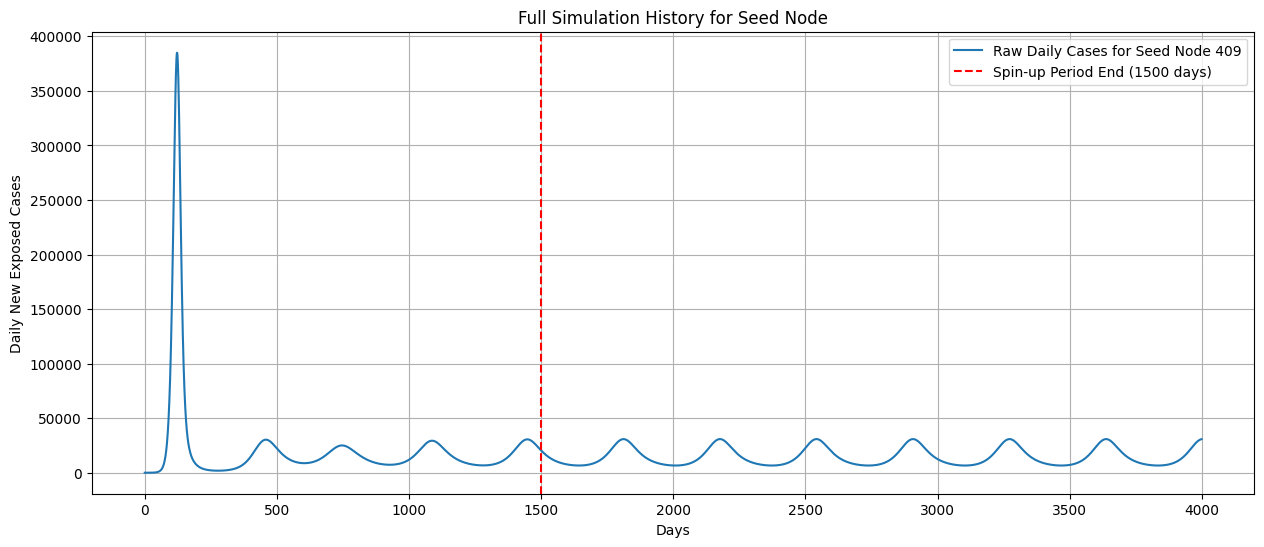

In [7]:
# --- Optional Diagnostic Plot ---
# This plots the raw simulation output for the seed node over the ENTIRE period (including spin-up)
# to confirm that stable, periodic cycles have been established.

seed_idx = population_df['population'].idxmax()
plt.figure(figsize=(15, 6))
plt.plot(raw_simulation_output[:, seed_idx], label=f"Raw Daily Cases for Seed Node {seed_idx}")
plt.axvline(x=T_SPIN_UP, color='r', linestyle='--', label=f'Spin-up Period End ({T_SPIN_UP} days)')
plt.title("Full Simulation History for Seed Node")
plt.xlabel("Days")
plt.ylabel("Daily New Exposed Cases")
plt.legend()
plt.grid(True)
plt.show()

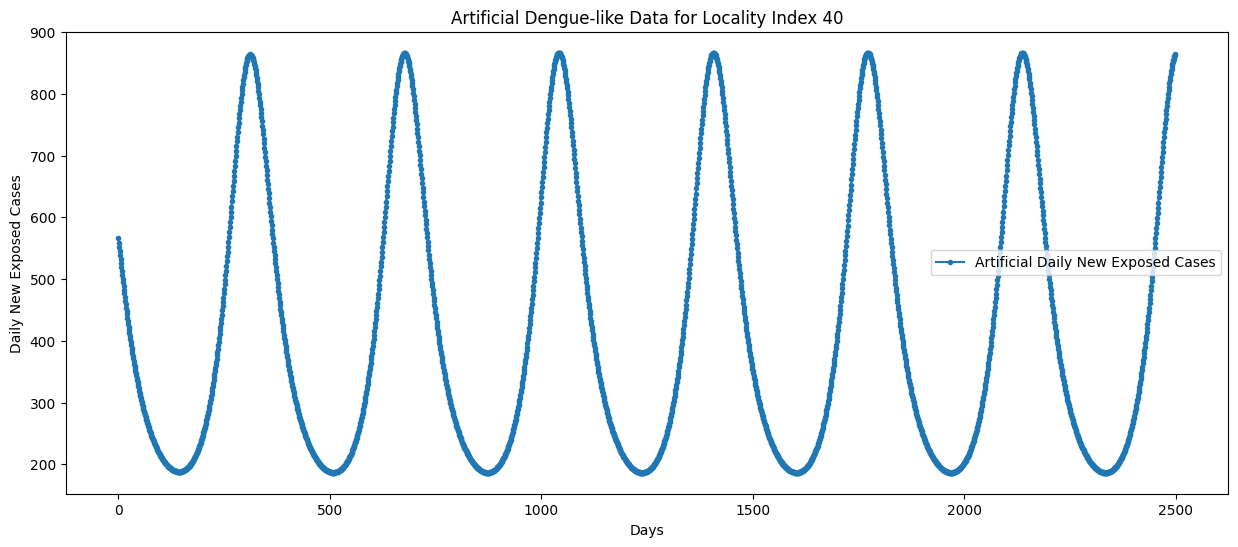

In [8]:
index=40
plt.figure(figsize=(15, 6))
plt.plot(dengue_array[:, index], label="Artificial Daily New Exposed Cases", marker='.')
plt.title(f"Artificial Dengue-like Data for Locality Index {index}")
plt.xlabel("Days")
plt.ylabel("Daily New Exposed Cases")
plt.legend()    

Creating tf dataset

In [9]:
# Define hyperparameters for creating the time-series sequences
input_sequence_length = 12
forecast_horizon = 3
batch_size = 32


# Define the function to create TensorFlow datasets
def create_tf_dataset(
    data_array: np.ndarray,
    input_sequence_length: int,
    forecast_horizon: int,
    batch_size: int = 32,
    shuffle=True,
    multi_horizon=True,
):
    """Creates a TensorFlow dataset from a NumPy array."""
    
    # Create inputs using sliding windows on the data array
    inputs = tf.keras.preprocessing.timeseries_dataset_from_array(
        np.expand_dims(data_array[:-forecast_horizon], axis=-1),
        None,
        sequence_length=input_sequence_length,
        shuffle=False,
        batch_size=batch_size,
    )

    # Determine the starting point for the target sequences
    target_offset = (
        input_sequence_length if multi_horizon else input_sequence_length + forecast_horizon - 1
    )
    target_seq_length = forecast_horizon if multi_horizon else 1
    
    # Create targets using sliding windows
    targets = tf.keras.preprocessing.timeseries_dataset_from_array(
        data_array[target_offset:],
        None,
        sequence_length=target_seq_length,
        shuffle=False,
        batch_size=batch_size,
    )

    # Zip inputs and targets together into a single dataset
    dataset = tf.data.Dataset.zip((inputs, targets))
    if shuffle:
        dataset = dataset.shuffle(100)

    # Prefetch and cache for performance
    return dataset.prefetch(16).cache()


# # Create the final training and validation datasets
# train_dataset = create_tf_dataset(
#     train_array, input_sequence_length, forecast_horizon, batch_size, multi_horizon=False
# )
# val_dataset = create_tf_dataset(
#     val_array, input_sequence_length, forecast_horizon, batch_size, shuffle=False, multi_horizon=False
# )

# print("TensorFlow datasets created successfully.")

Gravity Model

In [10]:
def create_sparse_gravity_matrix(
    df: pd.DataFrame, 
    population_col='population', 
    lat_col='latitude', 
    lon_col='longitude',
    p_cutoff=90 # Keep the top 10% of all weighted edges (100 - 90)
):
    """
    Creates a sparse, row-normalized, weighted adjacency matrix based on a gravity model,
    keeping only the edges with weights above a certain percentile cutoff.
    """
    num_nodes = len(df)
    populations = df[population_col].values
    coords = np.radians(df[[lat_col, lon_col]].values)

    # 1. Calculate the pairwise Haversine distance matrix
    lat = coords[:, 0]
    lon = coords[:, 1]
    dlat = lat[:, np.newaxis] - lat
    dlon = lon[:, np.newaxis] - lon
    a = np.sin(dlat / 2.0)**2 + np.cos(lat[:, np.newaxis]) * np.cos(lat) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance_matrix = 6371 * c

    # 2. Calculate the population interaction term
    pop_matrix = np.outer(populations, populations)

    # 3. Calculate the gravity model scores
    with np.errstate(divide='ignore', invalid='ignore'):
        gravity_matrix = pop_matrix / (distance_matrix**2)
    np.fill_diagonal(gravity_matrix, 0)
    gravity_matrix[~np.isfinite(gravity_matrix)] = 0
    
    # --- Sparsify the Graph ---
    # 4. Keep only the most significant edges
    all_edges = gravity_matrix[gravity_matrix > 0]
    if len(all_edges) == 0:
        return np.zeros_like(gravity_matrix) # Return empty matrix if no edges exist
        
    cutoff_value = np.percentile(all_edges, p_cutoff)
    
    sparse_gravity_matrix = gravity_matrix.copy()
    sparse_gravity_matrix[sparse_gravity_matrix < cutoff_value] = 0

    # 5. Re-normalize the sparse matrix by row
    row_sums = sparse_gravity_matrix.sum(axis=1)
    row_sums[row_sums == 0] = 1.0 # Avoid division by zero
    
    normalized_adj_matrix = sparse_gravity_matrix / row_sums[:, np.newaxis]
    
    return normalized_adj_matrix

# --- Define the GraphInfo Class ---
class GraphInfo:
    def __init__(self, edges: typing.Tuple[list, list], edge_weights: list, num_nodes: int):
        self.edges = edges
        self.edge_weights = edge_weights
        self.num_nodes = num_nodes

# --- Initialize the Graph ---
# This is a hyperparameter you can tune
p_cutoff = 97 
weighted_adjacency_matrix = create_sparse_gravity_matrix(population_df, p_cutoff=p_cutoff)

# Find the edges and their corresponding weights from the sparse matrix
node_indices, neighbor_indices = np.where(weighted_adjacency_matrix > 0)
edge_weights = weighted_adjacency_matrix[node_indices, neighbor_indices]

graph = GraphInfo(
    edges=(node_indices.tolist(), neighbor_indices.tolist()),
    edge_weights=edge_weights.tolist(),
    num_nodes=weighted_adjacency_matrix.shape[0],
)

print(f"Sparse gravity graph initialized with a {p_cutoff}th percentile cutoff.")
print(f"Graph has {graph.num_nodes} nodes and {len(graph.edges[0])} edges.")

Sparse gravity graph initialized with a 97th percentile cutoff.
Graph has 558 nodes and 9326 edges.


GraphConv

In [11]:
class GraphConv(layers.Layer):
    def __init__(
        self,
        in_feat,
        out_feat,
        graph_info: GraphInfo,
        combination_type="concat",
        activation: typing.Optional[str] = None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.in_feat = in_feat
        self.out_feat = out_feat
        self.graph_info = graph_info
        self.combination_type = combination_type
        
        self.edge_weights = tf.constant(graph_info.edge_weights, dtype="float32")

        self.weight = tf.Variable(
            initial_value=keras.initializers.glorot_uniform()(
                shape=(in_feat, out_feat), dtype="float32"
            ),
            trainable=True,
        )
        self.activation = layers.Activation(activation)

    def aggregate(self, neighbour_representations: tf.Tensor):
        """
        Performs a weighted aggregation of neighbor features.
        The formula is: sum(features * weights) / sum(weights)
        """
        # Reshape edge weights to multiply with neighbor features
        weights_reshaped = tf.reshape(self.edge_weights, (-1, 1, 1, 1))
        weighted_neighbors = neighbour_representations * weights_reshaped
        
        # Calculate the numerator of the weighted mean
        numerator = tf.math.unsorted_segment_sum(
            data=weighted_neighbors,
            segment_ids=self.graph_info.edges[0],
            num_segments=self.graph_info.num_nodes
        )
        
        # --- CORRECTED PART ---
        # Calculate the denominator (sum of weights for each node)
        denominator = tf.math.unsorted_segment_sum(
            data=self.edge_weights,
            segment_ids=self.graph_info.edges[0],
            num_segments=self.graph_info.num_nodes
        )
        
        # Reshape denominator for broadcasting across all dimensions
        # Shape changes from (num_nodes,) to (num_nodes, 1, 1, 1)
        denominator_reshaped = tf.reshape(denominator, (-1, 1, 1, 1))
        
        # Avoid division by zero
        denominator_reshaped = tf.where(denominator_reshaped == 0, 1.0, denominator_reshaped)
        
        return numerator / denominator_reshaped

    def compute_nodes_representation(self, features: tf.Tensor):
        return tf.matmul(features, self.weight)

    def compute_aggregated_messages(self, features: tf.Tensor):
        neighbour_representations = tf.gather(features, self.graph_info.edges[1])
        aggregated_messages = self.aggregate(neighbour_representations)
        return tf.matmul(aggregated_messages, self.weight)

    def update(self, nodes_representation: tf.Tensor, aggregated_messages: tf.Tensor):
        if self.combination_type == "concat":
            h = tf.concat([nodes_representation, aggregated_messages], axis=-1)
        elif self.combination_type == "add":
            h = nodes_representation + aggregated_messages
        else:
            raise ValueError(f"Invalid combination type: {self.combination_type}.")
        return self.activation(h)

    def call(self, features: tf.Tensor):
        nodes_representation = self.compute_nodes_representation(features)
        aggregated_messages = self.compute_aggregated_messages(features)
        return self.update(nodes_representation, aggregated_messages)

In [12]:
class LSTMGC(layers.Layer):
    """Layer comprising a graph convolution layer followed by an LSTM and dense layer."""

    def __init__(
        self,
        in_feat,
        out_feat,
        lstm_units: int,
        input_seq_len: int,
        output_seq_len: int,
        graph_info: GraphInfo,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.graph_conv = GraphConv(in_feat, out_feat, graph_info)
        self.lstm = layers.LSTM(lstm_units, activation="relu")
        self.dense = layers.Dense(output_seq_len)
        self.input_seq_len = input_seq_len
        self.output_seq_len = output_seq_len

    def call(self, inputs):
        """Forward pass."""
        # Reshape for GraphConv
        inputs = tf.transpose(inputs, [2, 0, 1, 3])

        gcn_out = self.graph_conv(inputs)
        
        shape = tf.shape(gcn_out)
        num_nodes, batch_size, input_seq_len, out_feat = (
            shape[0], shape[1], shape[2], shape[3]
        )

        # Reshape for LSTM
        gcn_out = tf.reshape(gcn_out, (batch_size * num_nodes, input_seq_len, out_feat))
        lstm_out = self.lstm(gcn_out)

        # Final prediction
        dense_output = self.dense(lstm_out)
        output = tf.reshape(dense_output, (num_nodes, batch_size, self.output_seq_len))
        
        # Reshape back to a user-friendly format
        return tf.transpose(output, [1, 2, 0])

print("LSTMGC layer defined successfully.")

LSTMGC layer defined successfully.


In [13]:
# # --- New Cell for Cross-Validation ---
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.preprocessing import MinMaxScaler
# import time

# # --- 1. Define Model Hyperparameters ---
# in_feat = 1
# out_feat = 4
# lstm_units = 32
# epochs = 20
# output_sequence_length = 1
# input_sequence_length = 12
# forecast_horizon = 1
# batch_size = 32

# # --- 2. Set up Time Series Cross-Validation ---
# n_splits = 3
# tscv = TimeSeriesSplit(n_splits=n_splits)

# validation_scores = []
# print(f"Starting Time Series Cross-Validation with {n_splits} splits...")
# print("This will take a few moments as the model is trained multiple times.")

# for fold, (train_indices, val_indices) in enumerate(tscv.split(train_val_array)):
#     print(f"\n--- FOLD {fold + 1}/{n_splits} ---")
    
#     # Create and preprocess data for the current fold
#     train_fold, val_fold = train_val_array[train_indices], train_val_array[val_indices]
#     scaler = MinMaxScaler()
#     train_fold_norm = scaler.fit_transform(train_fold)
#     val_fold_norm = scaler.transform(val_fold)
    
#     # Create TensorFlow datasets for the current fold
#     train_dataset = create_tf_dataset(train_fold_norm, input_sequence_length, forecast_horizon, batch_size, multi_horizon=False)
#     val_dataset = create_tf_dataset(val_fold_norm, input_sequence_length, forecast_horizon, batch_size, shuffle=False, multi_horizon=False)
    
#     # Re-initialize and train the model for this fold
#     input_layer = layers.Input(shape=(input_sequence_length, graph.num_nodes, in_feat))
#     st_gcn_layer = LSTMGC(in_feat, out_feat, lstm_units, input_sequence_length, output_sequence_length, graph)
#     outputs = st_gcn_layer(input_layer)
#     model = keras.models.Model(inputs=input_layer, outputs=outputs)
    
#     model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss=keras.losses.MeanSquaredError())
    
#     model.fit(train_dataset, epochs=epochs, validation_data=val_dataset,
#               callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])
    
#     # Evaluate and store the score for this fold
#     x_val, y_val_true_norm = next(iter(val_dataset))
#     y_val_pred_norm = model.predict(x_val)

#     pred_denorm = scaler.inverse_transform(y_val_pred_norm.reshape(-1, graph.num_nodes)).reshape(y_val_pred_norm.shape)
#     true_denorm = scaler.inverse_transform(y_val_true_norm.numpy().reshape(-1, graph.num_nodes)).reshape(y_val_true_norm.shape)
    
#     fold_mae = np.mean(np.abs(pred_denorm - true_denorm))
#     validation_scores.append(fold_mae)
#     print(f"MAE for Fold {fold + 1}: {fold_mae:.2f} cases")

# # --- Final Cross-Validation Performance ---
# print("\n--- Cross-Validation Summary ---")
# print(f"Validation MAE scores for each fold: {[f'{s:.2f}' for s in validation_scores]}")
# print(f"Average Validation MAE: {np.mean(validation_scores):.2f} cases")

In [14]:
# --- 1. Define Model Hyperparameters ---
in_feat = 1
out_feat = 4
lstm_units = 32
epochs = 20
output_sequence_length = 1
# input_sequence_length and forecast_horizon are already defined
batch_size = 32

# --- 2. Final Model Training ---
print("\n--- Final Model Training (STGCN) ---")

# Prepare the full training/validation dataset (now 400 steps long)
full_train_val_scaler = MinMaxScaler()
full_train_val_norm = full_train_val_scaler.fit_transform(train_val_array)
full_train_dataset = create_tf_dataset(full_train_val_norm, input_sequence_length, forecast_horizon, batch_size, multi_horizon=False)

# Re-initialize and train the final model on ALL training/validation data
final_input_layer = layers.Input(shape=(input_sequence_length, graph.num_nodes, in_feat))
final_st_gcn_layer = LSTMGC(in_feat, out_feat, lstm_units, input_sequence_length, output_sequence_length, graph)
final_outputs = final_st_gcn_layer(final_input_layer)
final_model = keras.models.Model(inputs=final_input_layer, outputs=final_outputs)
final_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss=keras.losses.MeanAbsoluteError())

print(f"Training final STGCN model on all {train_val_size} time steps...")
final_model.fit(full_train_dataset, epochs=epochs, 
                callbacks=[keras.callbacks.EarlyStopping(monitor="loss", patience=5)], # Monitor training loss
                verbose=0)

print("STGCN Training complete.")


--- Final Model Training (STGCN) ---


2025-11-12 14:52:51.654112: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training final STGCN model on all 2000 time steps...
STGCN Training complete.


STGCN Training complete.

--- Final STGCN Evaluation on Hold-Out Test Set ---
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step
Final Hold-Out Test MAE: 19.01 cases
Final Hold-Out Test sMAPE: 4.85%
Final Hold-Out Test MASE: 6.29 (Value < 1 is better than a naive forecast)



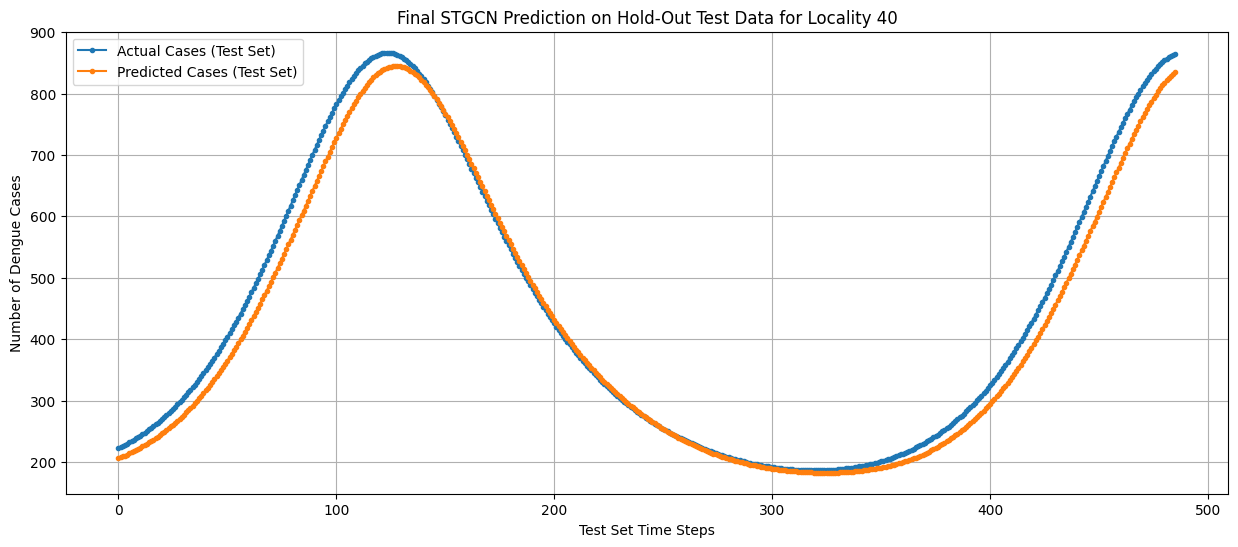

In [15]:
# ... (After final_model.fit(...) is complete) ...

print("STGCN Training complete.")

# --- 3. Final Evaluation on Hold-Out Test Set ---
print("\n--- Final STGCN Evaluation on Hold-Out Test Set ---")

# Prepare the test dataset
test_norm = full_train_val_scaler.transform(test_array)
test_dataset = create_tf_dataset(test_norm, input_sequence_length, forecast_horizon, batch_size, shuffle=False, multi_horizon=False)

# Evaluate the model to get predictions for the entire test set
y_test_pred_norm = final_model.predict(test_dataset)

# --- *** THE FIX IS HERE *** ---
# Squeeze the 3D prediction array (samples, 1, nodes) into a 2D array (samples, nodes)
pred_2d = np.squeeze(y_test_pred_norm, axis=1)

# Now, inverse_transform will work correctly on the 2D array
pred_denorm_stgcn = full_train_val_scaler.inverse_transform(pred_2d)
pred_denorm_stgcn = np.clip(pred_denorm_stgcn, 0, None)

# The true values also need to be shaped correctly for comparison
true_denorm_stgcn = test_array[input_sequence_length + forecast_horizon - 1:]

# Ensure shapes align for metric calculation (in case of batching remainders)
min_len = min(len(true_denorm_stgcn), len(pred_denorm_stgcn))
true_denorm_stgcn = true_denorm_stgcn[:min_len]
pred_denorm_stgcn = pred_denorm_stgcn[:min_len]

# --- 4. Report final metrics ---
# Mean Absolute Error (MAE)
final_mae = np.mean(np.abs(pred_denorm_stgcn - true_denorm_stgcn))

# Symmetric Mean Absolute Percentage Error (sMAPE)
epsilon = 1e-8
final_smape = np.mean(2 * np.abs(pred_denorm_stgcn - true_denorm_stgcn) / (np.abs(true_denorm_stgcn) + np.abs(pred_denorm_stgcn) + epsilon)) * 100

# Mean Absolute Scaled Error (MASE)
naive_error = np.mean(np.abs(train_val_array[1:] - train_val_array[:-1]))
final_mase = final_mae / naive_error

print(f"Final Hold-Out Test MAE: {final_mae:.2f} cases")
print(f"Final Hold-Out Test sMAPE: {final_smape:.2f}%")
print(f"Final Hold-Out Test MASE: {final_mase:.2f} (Value < 1 is better than a naive forecast)\n")


# --- 5. Visualize final results ---
locality_index = 40
plt.figure(figsize=(15, 6))
# Plot using the correctly shaped 2D arrays
plt.plot(true_denorm_stgcn[:, locality_index], label="Actual Cases (Test Set)", marker='.')
plt.plot(pred_denorm_stgcn[:, locality_index], label="Predicted Cases (Test Set)", marker='.')
plt.title(f'Final STGCN Prediction on Hold-Out Test Data for Locality {locality_index}')
plt.xlabel("Test Set Time Steps")
plt.ylabel("Number of Dengue Cases")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# --- 1. Define and Compile the Multi-Variate LSTM Model ---
print("--- Building Multi-Variate LSTM Model (No Graph) ---")

lstm_input_layer = layers.Input(shape=(input_sequence_length, graph.num_nodes))
lstm_layer = layers.LSTM(32)(lstm_input_layer)
lstm_output_layer = layers.Dense(graph.num_nodes)(lstm_layer)
lstm_model = keras.models.Model(inputs=lstm_input_layer, outputs=lstm_output_layer)

lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mean_absolute_error')
lstm_model.summary()

# --- 2. Prepare Data for a Standard LSTM ---
def adjust_shapes_for_lstm(x, y):
    return tf.squeeze(x, axis=-1), tf.squeeze(y, axis=1)

lstm_full_train_dataset = full_train_dataset.map(adjust_shapes_for_lstm)
lstm_test_dataset = test_dataset.map(adjust_shapes_for_lstm)

# --- 3. Train the LSTM Model ---
print("\n--- Training Multi-Variate LSTM Model ---")
lstm_model.fit(
    lstm_full_train_dataset,
    epochs=100,
    callbacks=[keras.callbacks.EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)],
    verbose=0
)

# --- 4. Evaluate and Store Predictions ---
print("\n--- Evaluating Multi-Variate LSTM on Test Set ---")
x_test_lstm, y_test_true_norm_lstm = next(iter(lstm_test_dataset))
y_test_pred_norm_lstm = lstm_model.predict(x_test_lstm)

# De-normalize and store predictions in a new variable
pred_denorm_lstm = full_train_val_scaler.inverse_transform(y_test_pred_norm_lstm)
true_denorm_lstm = full_train_val_scaler.inverse_transform(y_test_true_norm_lstm.numpy())
pred_denorm_lstm = np.maximum(0, pred_denorm_lstm)

# --- 5. Report Final Metrics ---
final_mae_lstm = np.mean(np.abs(pred_denorm_lstm - true_denorm_lstm))
epsilon = 1e-8
final_smape_lstm = np.mean(2 * np.abs(pred_denorm_lstm - true_denorm_lstm) / (np.abs(true_denorm_lstm) + np.abs(pred_denorm_lstm) + epsilon)) * 100
naive_error = np.mean(np.abs(train_val_array[1:] - train_val_array[:-1]))
final_mase_lstm = final_mae_lstm / naive_error

print("\n--- Multi-Variate LSTM Model Performance ---")
print(f"Final Hold-Out Test MAE: {final_mae_lstm:.2f} cases")
print(f"Final Hold-Out Test sMAPE: {final_smape_lstm:.2f}%")
print(f"Final Hold-Out Test MASE: {final_mase_lstm:.2f} (Value < 1 is better than naive)")

--- Building Multi-Variate LSTM Model (No Graph) ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12, 558)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        75,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 558)            │        18,414 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,062 (367.43 KB)

 Trainable params: 94,062 (367.43 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Multi-Variate LSTM Model ---

--- Evaluating Multi-Variate LSTM on Test Set ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step

--- Multi-Variate LSTM Model Performance ---
Final Hold-Out Test MAE: 3.22 cases
Final Hold-Out Test sMAPE: 11.56%
Final Hold-Out Test MASE: 1.07 (Value < 1 is better than naive)


In [17]:
# --- 1. Define Localities and Setup ---
localities_to_test = [10, 150, 300, 500]
ensemble_preds = {}
ensemble_true = {}
# Use lstm as it's simpler and effective for the ensemble
ensemble_lstm_units = 32 

# --- 2. Helper function for windowing ---
def create_windows(data, input_seq_len, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - input_seq_len - forecast_horizon + 1):
        X.append(data[i:(i + input_seq_len), 0])
        y.append(data[i + input_seq_len + forecast_horizon - 1, 0])
    return np.array(X), np.array(y)

# --- 3. Loop, Train, and Predict for Each Selected Locality ---
print(f"--- Training Ensemble Models for 4 Localities: {localities_to_test} ---")

for i in localities_to_test:
    print(f"Training model for locality {i}...")
    
    single_locality_data = dengue_array[:, i].reshape(-1, 1)
    train_data = single_locality_data[:train_val_size]
    test_data = single_locality_data[train_val_size:]
    
    scaler_ensemble = MinMaxScaler()
    train_scaled = scaler_ensemble.fit_transform(train_data)
    test_scaled = scaler_ensemble.transform(test_data)
    
    X_train, y_train = create_windows(train_scaled, input_sequence_length, forecast_horizon)
    X_test, y_test = create_windows(test_scaled, input_sequence_length, forecast_horizon)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    lstm_model = Sequential([
        layers.Input(shape=(input_sequence_length, 1)),
        layers.LSTM(ensemble_lstm_units, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mean_absolute_error')
    
    lstm_model.fit(X_train, y_train, epochs=100,
                  callbacks=[keras.callbacks.EarlyStopping(monitor='loss', patience=10)],
                  verbose=0)
    
    predictions_scaled = lstm_model.predict(X_test, verbose=0)
    ensemble_preds[i] = np.maximum(0, scaler_ensemble.inverse_transform(predictions_scaled))
    ensemble_true[i] = scaler_ensemble.inverse_transform(y_test.reshape(-1, 1))

# --- 4. Aggregate and Evaluate the Performance ---
all_predictions_np = np.concatenate([ensemble_preds[i] for i in localities_to_test])
all_true_values_np = np.concatenate([ensemble_true[i] for i in localities_to_test])

final_mae_ensemble = np.mean(np.abs(all_predictions_np - all_true_values_np))
epsilon = 1e-8
final_smape_ensemble = np.mean(2 * np.abs(all_predictions_np - all_true_values_np) / (np.abs(all_true_values_np) + np.abs(all_predictions_np) + epsilon)) * 100
naive_error = np.mean(np.abs(train_val_array[1:] - train_val_array[:-1]))
final_mase_ensemble = final_mae_ensemble / naive_error

print("\n--- Aggregate Performance of Ensemble Model (4 Localities) ---")
print(f"Final Test MAE: {final_mae_ensemble:.2f} cases")
print(f"Final Test sMAPE: {final_smape_ensemble:.2f}%")
print(f"Final Test MASE: {final_mase_ensemble:.2f} (Value < 1 is better than naive)")

--- Training Ensemble Models for 4 Localities: [10, 150, 300, 500] ---
Training model for locality 10...


NameError: name 'Sequential' is not defined

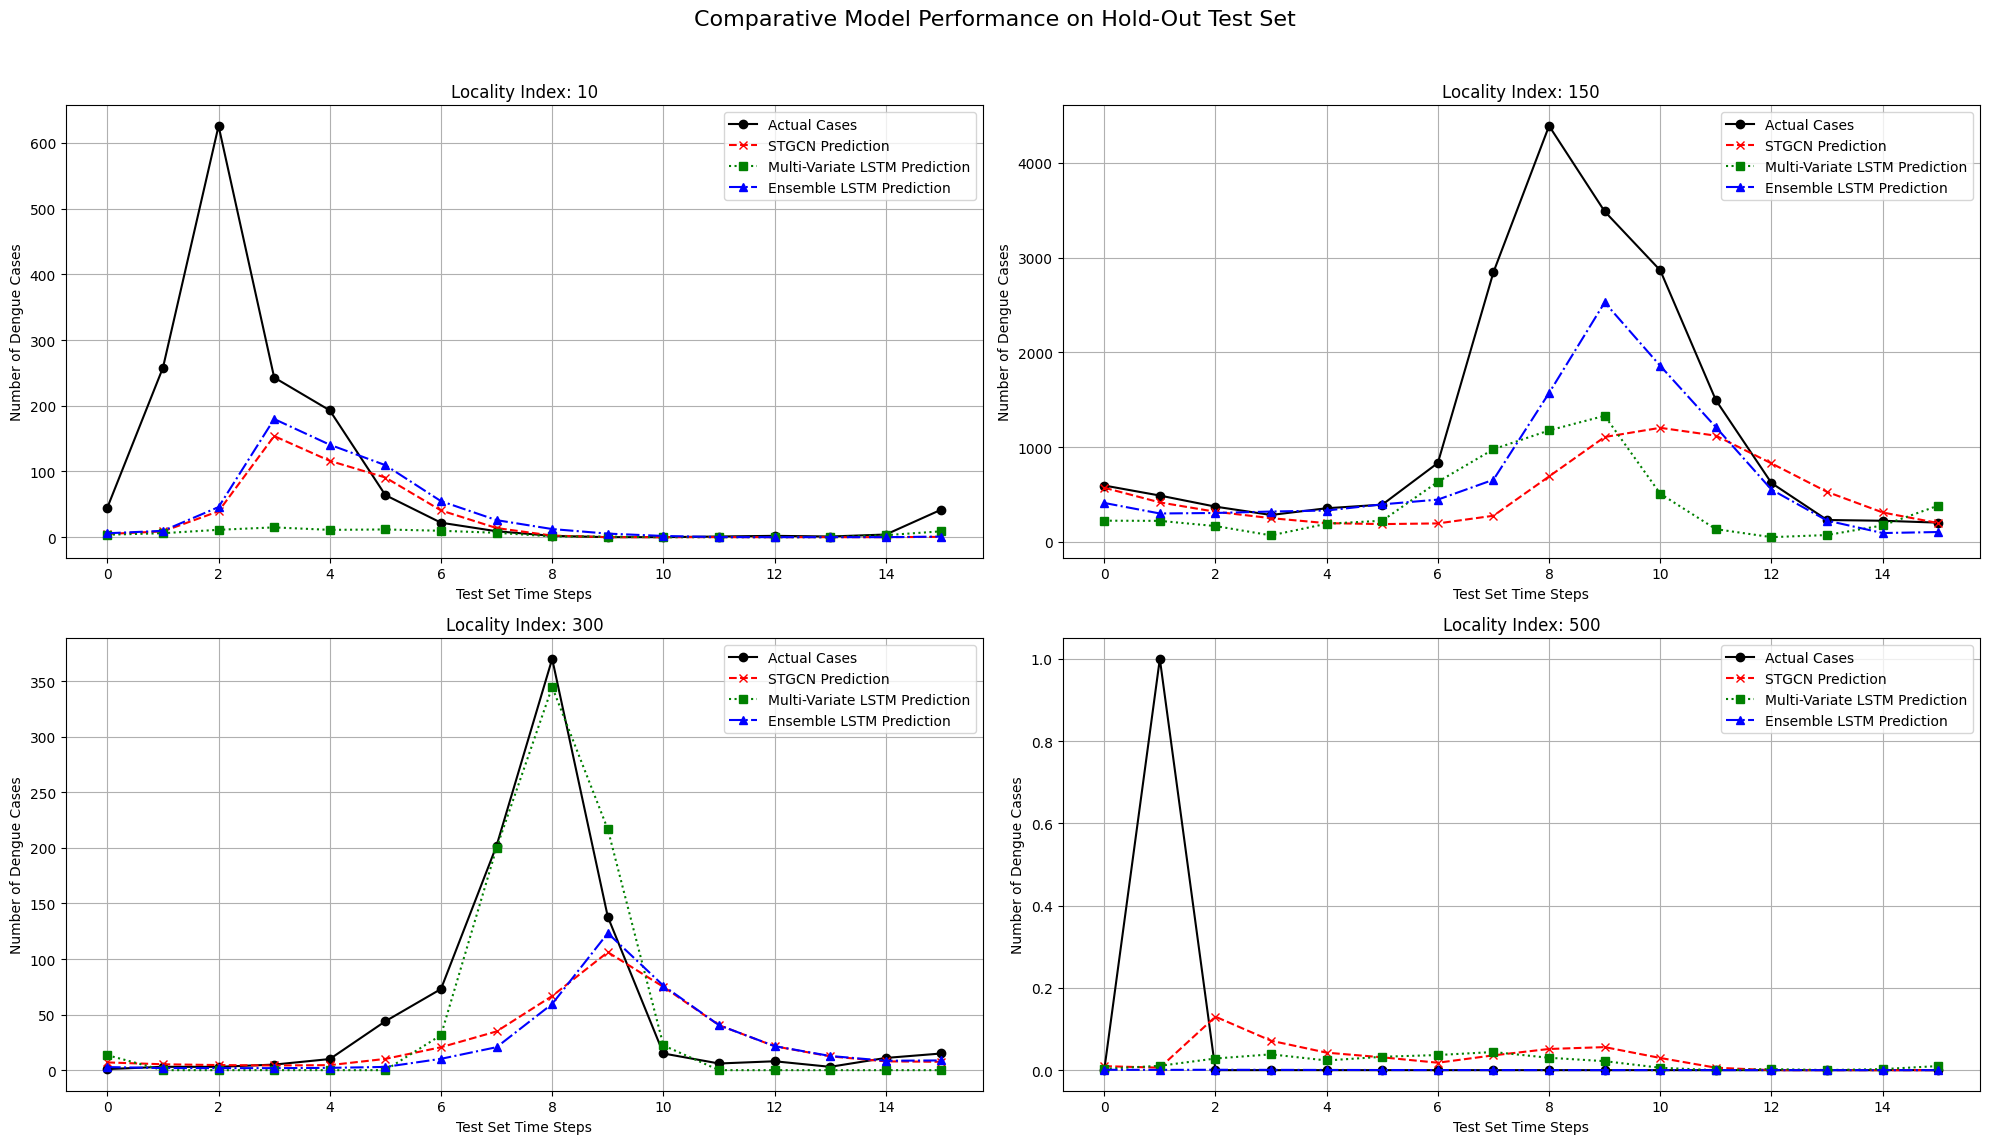

In [ ]:
# --- Plotting the Comparative Results ---
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Comparative Model Performance on Hold-Out Test Set', fontsize=16)
axes = axes.flatten() # Flatten the 2x2 grid for easy iteration

for i, locality_idx in enumerate(localities_to_test):
    ax = axes[i]
    
    # Plot Actual Cases
    # Note: We use the test data from the ensemble for the true values
    ax.plot(ensemble_true[locality_idx].flatten(), label="Actual Cases", marker='o', linestyle='-', color='black')
    
    # Plot STGCN Predictions
    # We need to find the correct number of test samples to plot
    num_test_samples = len(ensemble_true[locality_idx])
    ax.plot(pred_denorm_stgcn[:num_test_samples, 0, locality_idx], label="STGCN Prediction", marker='x', linestyle='--', color='red')
    
    # Plot Multi-Variate LSTM Predictions
    ax.plot(pred_denorm_lstm[:num_test_samples, locality_idx], label="Multi-Variate LSTM Prediction", marker='s', linestyle=':', color='green')
    
    # Plot Ensemble Model Predictions
    ax.plot(ensemble_preds[locality_idx].flatten(), label="Ensemble LSTM Prediction", marker='^', linestyle='-.', color='blue')
    
    ax.set_title(f'Locality Index: {locality_idx}')
    ax.set_xlabel("Test Set Time Steps")
    ax.set_ylabel("Number of Dengue Cases")
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
import time

# --- 1. Define Hyperparameters and Setup ---
input_sequence_length = 12
forecast_horizon = 1
lstm_units = 32
epochs = 100
train_val_size = 200 # Using the same split point as before

# Select 25 localities spread evenly across the 558 indices
num_localities_to_test = 70
localities_to_test = np.linspace(0, dengue_array.shape[1] - 1, num_localities_to_test, dtype=int)

all_predictions = []
all_true_values = []

# --- 2. Helper function to create time-series windows ---
def create_windows(data, input_seq_len, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - input_seq_len - forecast_horizon + 1):
        X.append(data[i:(i + input_seq_len), 0])
        y.append(data[i + input_seq_len + forecast_horizon - 1, 0])
    return np.array(X), np.array(y)

# --- 3. Loop through each locality, train a model, and predict ---
print(f"Starting to train an ensemble of {num_localities_to_test} independent LSTM models...")
start_time = time.time()

for i in localities_to_test:
    print(f"\rTraining model for locality {i}...", end="")

    # Isolate and split data for the current locality
    single_locality_data = dengue_array[:, i].reshape(-1, 1)
    train_data = single_locality_data[:train_val_size]
    test_data = single_locality_data[train_val_size:]

    # Scale data for this specific locality
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)

    # Create time-series windows
    X_train, y_train = create_windows(train_scaled, input_sequence_length, forecast_horizon)
    X_test, y_test = create_windows(test_scaled, input_sequence_length, forecast_horizon)

    # Reshape input for LSTM layer
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # Skip if there's no test data to predict on
    if len(X_test) == 0:
        continue

    # Build and train a new LSTM model
    lstm_model = Sequential([
        layers.Input(shape=(input_sequence_length, 1)),
        layers.GRU(lstm_units, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mean_absolute_error')

    lstm_model.fit(
        X_train, y_train,
        epochs=epochs,
        callbacks=[keras.callbacks.EarlyStopping(monitor='loss', patience=10)],
        verbose=0
    )

    # Predict and de-normalize
    predictions_scaled = lstm_model.predict(X_test, verbose=0)
    predictions = scaler.inverse_transform(predictions_scaled)
    true_values = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Store results
    all_predictions.append(predictions)
    all_true_values.append(true_values)

end_time = time.time()
print(f"\n\nTraining finished in {end_time - start_time:.2f} seconds.")

# --- 4. Aggregate and Evaluate the Performance of All Models Combined ---
# Concatenate results from all localities into single arrays
all_predictions_np = np.concatenate(all_predictions)
all_true_values_np = np.concatenate(all_true_values)
all_predictions_np = np.maximum(0, all_predictions_np) # Clip negatives

# Calculate aggregate metrics
final_mae_ensemble = np.mean(np.abs(all_predictions_np - all_true_values_np))
epsilon = 1e-8
final_smape_ensemble = np.mean(2 * np.abs(all_predictions_np - all_true_values_np) / (np.abs(all_true_values_np) + np.abs(all_predictions_np) + epsilon)) * 100
train_val_array = dengue_array[:train_val_size]
naive_error = np.mean(np.abs(train_val_array[1:] - train_val_array[:-1]))
final_mase_ensemble = final_mae_ensemble / naive_error

print("\n--- Aggregate Performance of Ensemble Model on Test Set ---")
print(f"Final Test MAE: {final_mae_ensemble:.2f} cases")
print(f"Final Test sMAPE: {final_smape_ensemble:.2f}%")
print(f"Final Test MASE: {final_mase_ensemble:.2f} (Value < 1 is better than naive)")

Starting to train an ensemble of 70 independent LSTM models...
Training model for locality 40...

KeyboardInterrupt: 